# SAMPIC waveform explorer — fake-MIDAS full chain

Reads the RNTuple written by the Gaudi chain
(`converter/bin_to_mid.py` → `PIMidasSelector` → `PITMidasSampic` → `PIAOutputStream`)
and dumps/plots the decoded waveforms. These plots are the starting point for the
reconstruction algorithms (energy calibration, pulse fitting, timing).

Run inside the `pioneer-midas` container (`scripts/run_container.sh`, then
`scripts/run_jupyter.sh`). The last section cross-checks against the reference
`dat_to_root` output shipped with the example run.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

WORKDIR = Path("/workdir")
REC_FILE = WORKDIR / "sampic-to-midas/output/run914_rec.root"
# Regenerated with the original dat_to_root (channel arg = 2, see README);
# the .root shipped in data/ is empty: dat_to_root's channel filter defaults
# to 0 while all run914 hits are on channel 2.
REFERENCE_FILE = (WORKDIR / "sampic-to-midas/output/reference"
                  / "W9PIN_14MeV_0deg_100V_run914_ch2.root")
GAP_NS = 100.0          # converter --gap-ns used to build the events
DT_NS = 1e3 / 6400      # 6400 MS/s -> 0.15625 ns / sample

# Okabe-Ito (colorblind-safe); one hue per role, fixed assignment
C_MAIN = "#0072B2"      # this chain
C_REF = "#D55E00"       # dat_to_root reference
C_MUTED = "#999999"

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

## Load the `rec` RNTuple

Primary reader is **uproot**; if it cannot interpret the RNTuple, the fallback
cell uses **PyROOT** `RNTupleReader` (the same ROOT that wrote the file).
Everything downstream consumes flat numpy arrays, so the reader choice does not
matter:

- `ev_index[i]` — Gaudi event of hit *i*, plus per-hit `channel`, `amplitude`,
  `baseline`, `tot`, `time_instant`, `t0` (`first_cell_timestamp`, ns)
- `wf[i]` — 64-slot corrected waveform in volts (zero-padded past `data_size`)

Note: the chain writes two hit-less bookkeeping entries (the first and the
last, from event-loop priming and the EOF probe of `PIMidasSelector`); they
flatten away harmlessly and are reported separately below.

For files much larger than this demo, switch the uproot call to
`uproot.iterate`-style batches and histogram incrementally instead of holding
all waveforms in memory (42k hits x 64 samples here is ~11 MB, fine).

In [2]:
def load_rec_uproot(path):
    import awkward as ak
    import uproot

    rn = uproot.open(path)["rec"]
    # NOTE: uproot's RNTuple filter_name matches subfield paths, so glob for
    # the hits container and navigate the awkward record from the top field.
    arr = rn.arrays(filter_name="*SampicEvent.hits*")
    hits = arr["_Event_SampicEvent"]["hits"]

    counts = ak.to_numpy(ak.num(hits, axis=1))
    flat = ak.flatten(hits, axis=1)
    wf = ak.fill_none(ak.pad_none(flat["corrected_waveform"], 64, axis=-1), 0.0)
    return {
        "n_events": len(counts),
        "counts": counts,
        "ev_index": np.repeat(np.arange(len(counts)), counts),
        "channel": ak.to_numpy(flat["channel"]),
        "amplitude": ak.to_numpy(flat["amplitude"]),
        "baseline": ak.to_numpy(flat["baseline"]),
        "tot": ak.to_numpy(flat["tot_value"]),
        "time_instant": ak.to_numpy(flat["time_instant"]),
        "t0": ak.to_numpy(flat["first_cell_timestamp"]),
        "wf": ak.to_numpy(wf).astype(np.float32),
    }


def load_rec_pyroot(path):
    """Fallback: same flat dict via PyROOT RNTupleReader (slower, python loop).

    Needs the EDM dictionary: source main's setenv.sh first so that
    libpi_unpacking is on the library path.
    """
    import ROOT

    ROOT.gSystem.Load("libpi_unpacking")
    reader = ROOT.RNTupleReader.Open("rec", str(path))
    entry = reader.GetModel().GetDefaultEntry()
    get_event = entry.GetPtr["PIUnpack::Sampic::Event"]
    rows, wfs, counts = [], [], []
    for i in range(reader.GetNEntries()):
        reader.LoadEntry(i)
        ev = get_event("_Event_SampicEvent")
        counts.append(len(ev.hits))
        for h in ev.hits:
            rows.append((i, h.channel, h.amplitude, h.baseline, h.tot_value,
                         h.time_instant, h.first_cell_timestamp))
            w = np.zeros(64, dtype=np.float32)
            w[:len(h.corrected_waveform)] = list(h.corrected_waveform)
            wfs.append(w)
    rows = np.array(rows)
    return {
        "n_events": len(counts),
        "counts": np.array(counts),
        "ev_index": rows[:, 0].astype(int),
        "channel": rows[:, 1].astype(int),
        "amplitude": rows[:, 2].astype(np.float32),
        "baseline": rows[:, 3].astype(np.float32),
        "tot": rows[:, 4].astype(np.float32),
        "time_instant": rows[:, 5],
        "t0": rows[:, 6],
        "wf": np.vstack(wfs),
    }


try:
    D = load_rec_uproot(REC_FILE)
    print("loaded with uproot")
except Exception as exc:
    print(f"uproot path failed ({type(exc).__name__}: {exc}); trying PyROOT")
    D = load_rec_pyroot(REC_FILE)

print(f"{D['n_events']} events, {len(D['channel'])} hits, "
      f"channels {sorted(set(D['channel']))}")

loaded with uproot
42260 events, 42258 hits, channels [np.int32(2)]


## Sanity counts and event multiplicity

entries          : 42260 (2 hit-less bookkeeping entries)
physics events   : 42258
hits             : 42258
hits/event       : min 0 / mean 1.00 / max 1
run duration     : 60.5 s


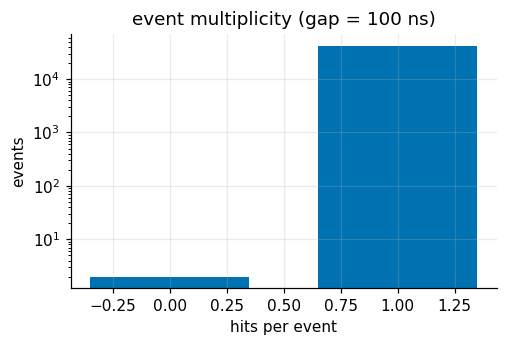

In [3]:
n_hits = len(D["channel"])
n_empty = int((D["counts"] == 0).sum())
print(f"entries          : {D['n_events']} "
      f"({n_empty} hit-less bookkeeping entries)")
print(f"physics events   : {D['n_events'] - n_empty}")
print(f"hits             : {n_hits}")
print(f"hits/event       : min {D['counts'].min()} / "
      f"mean {D['counts'].mean():.2f} / max {D['counts'].max()}")
print(f"run duration     : {(D['t0'].max() - D['t0'].min()) * 1e-9:.1f} s")

fig, ax = plt.subplots(figsize=(5, 3))
mult = np.bincount(D["counts"])
ax.bar(np.arange(len(mult)), mult, color=C_MAIN, width=0.7)
ax.set_yscale("log")
ax.set_xlabel("hits per event")
ax.set_ylabel("events")
ax.set_title(f"event multiplicity (gap = {GAP_NS:.0f} ns)")
plt.show()

## Single-event waveforms

First 16 hits, voltage vs time within the waveform window. The W9PIN pulses
in this run are positive-going, ~2.5 ns rise time; `baseline` and `amplitude`
are the values measured by the SAMPIC front-end itself (decoded from the AD
bank, not recomputed).

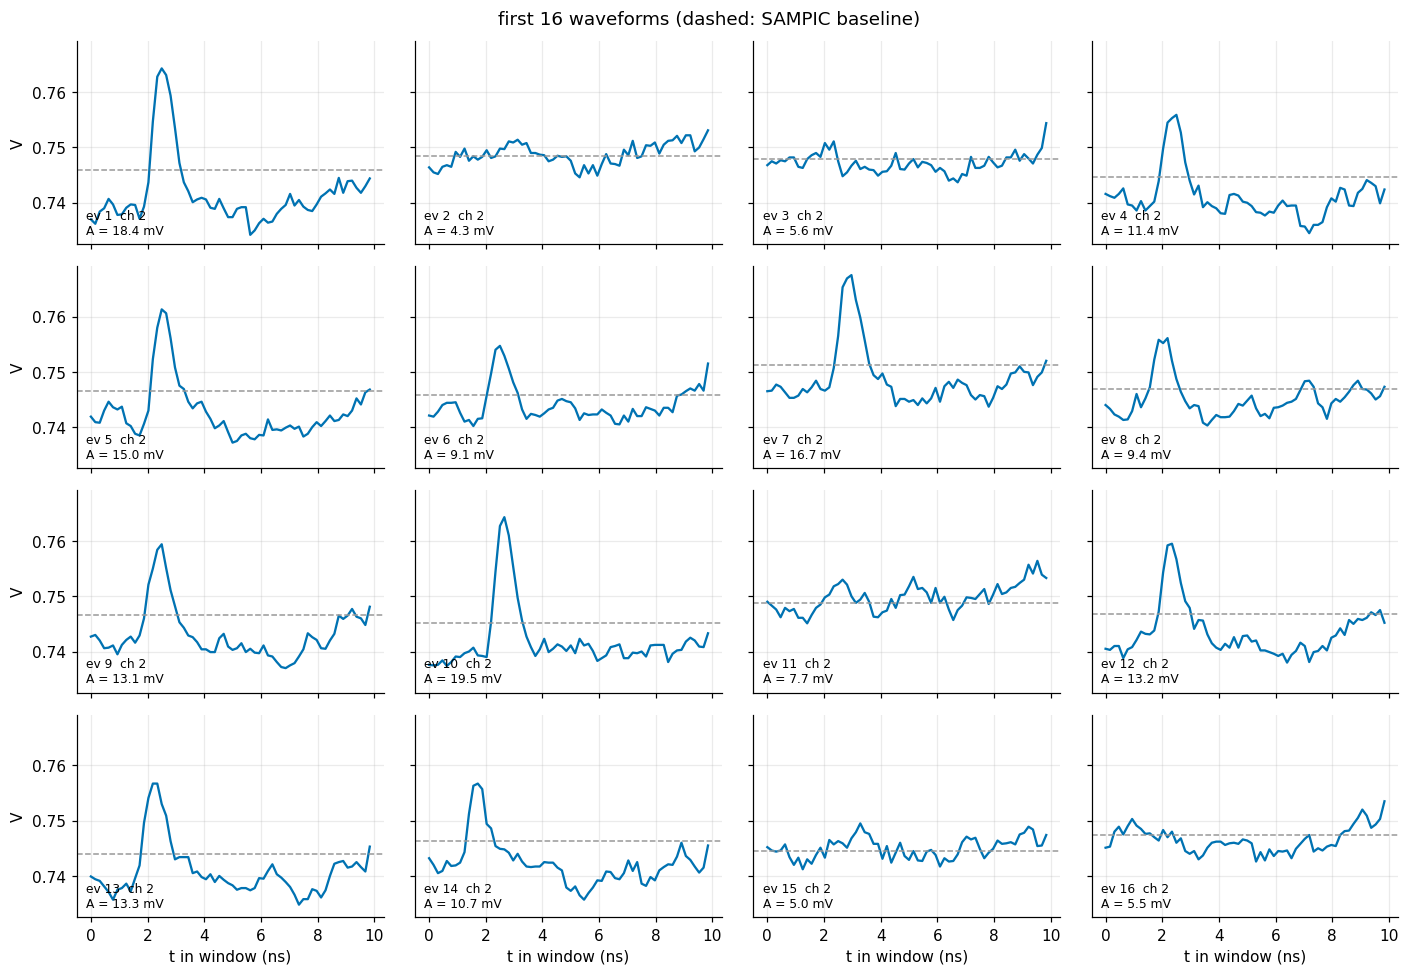

In [4]:
t_axis = np.arange(64) * DT_NS
fig, axes = plt.subplots(4, 4, figsize=(13, 9), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    if k >= len(D["wf"]):
        ax.axis("off")
        continue
    ax.plot(t_axis, D["wf"][k], color=C_MAIN, lw=1.5)
    ax.axhline(D["baseline"][k], color=C_MUTED, lw=1, ls="--")
    ax.annotate(f"ev {D['ev_index'][k]}  ch {D['channel'][k]}\n"
                f"A = {D['amplitude'][k] * 1e3:.1f} mV",
                xy=(0.03, 0.05), xycoords="axes fraction", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("t in window (ns)")
for ax in axes[:, 0]:
    ax.set_ylabel("V")
fig.suptitle("first 16 waveforms (dashed: SAMPIC baseline)")
fig.tight_layout()
plt.show()

## Waveform persistence

All waveforms overlaid as a 2D histogram of baseline-subtracted voltage per
sample index (memory-flat, works for millions of hits), plus a thin
alpha-overlay of the first 300 traces. Directly comparable to `hWaveform`
in the `dat_to_root` reference.

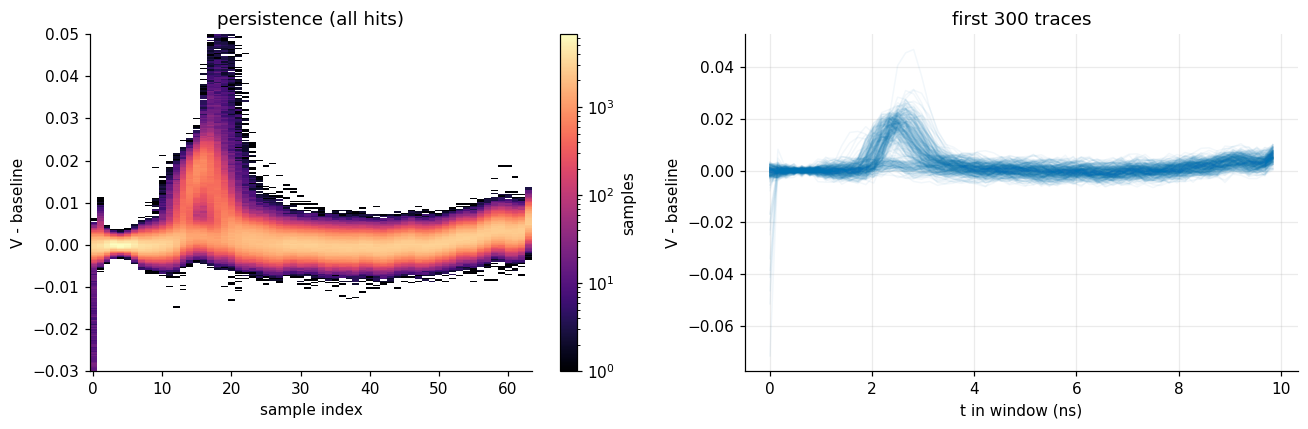

In [5]:
from matplotlib.colors import LogNorm

base_calc = D["wf"][:, 2:7].mean(axis=1)          # dat_to_root definition
dev = D["wf"] - base_calc[:, None]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sample_idx = np.tile(np.arange(64), len(dev))
h = ax1.hist2d(sample_idx, dev.ravel(),
               bins=[np.arange(65) - 0.5, np.linspace(-0.03, 0.05, 250)],
               cmap="magma", norm=LogNorm())
fig.colorbar(h[3], ax=ax1, label="samples")
ax1.set_xlabel("sample index")
ax1.set_ylabel("V - baseline")
ax1.set_title("persistence (all hits)")
ax1.grid(False)

for w in dev[:300]:
    ax2.plot(t_axis, w, color=C_MAIN, alpha=0.05, lw=1)
ax2.set_xlabel("t in window (ns)")
ax2.set_ylabel("V - baseline")
ax2.set_title("first 300 traces")
fig.tight_layout()
plt.show()

## Average waveform and pulse template

Per-channel mean of the baseline-subtracted waveforms, and the
amplitude-normalized template — the shape input for pulse fitting.

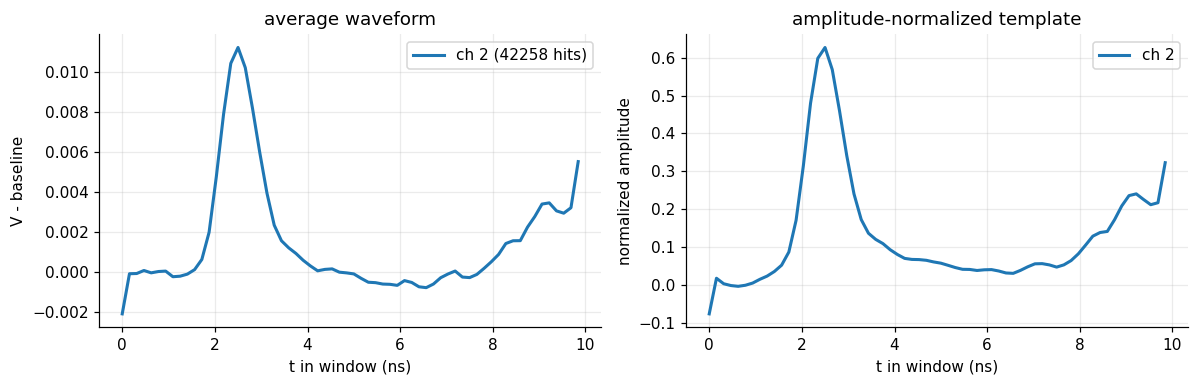

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
for ch in sorted(set(D["channel"])):
    sel = D["channel"] == ch
    avg = dev[sel].mean(axis=0)
    ax1.plot(t_axis, avg, lw=2, label=f"ch {ch} ({sel.sum()} hits)")

    sub = dev[sel][:, 3:62]
    amp_signed = np.take_along_axis(
        sub, np.abs(sub).argmax(axis=1)[:, None], axis=1)[:, 0]
    good = amp_signed != 0
    norm = dev[sel][good] / amp_signed[good, None]   # peak -> +1, any polarity
    ax2.plot(t_axis, norm.mean(axis=0), lw=2, label=f"ch {ch}")
ax1.set_xlabel("t in window (ns)")
ax1.set_ylabel("V - baseline")
ax1.set_title("average waveform")
ax1.legend()
ax2.set_xlabel("t in window (ns)")
ax2.set_ylabel("normalized amplitude")
ax2.set_title("amplitude-normalized template")
ax2.legend()
fig.tight_layout()
plt.show()

## Spectra

`amplitude`/`baseline` here are the SAMPIC front-end measurements carried
through the chain; ToT sentinel values (-1 = not measured) are shown separately.

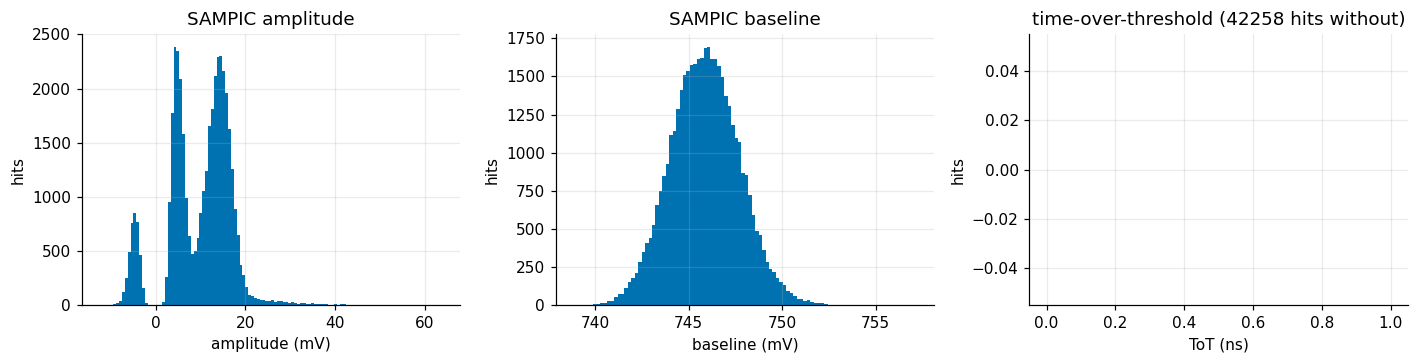

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(D["amplitude"] * 1e3, bins=120, color=C_MAIN)
axes[0].set_xlabel("amplitude (mV)")
axes[0].set_title("SAMPIC amplitude")
axes[1].hist(D["baseline"] * 1e3, bins=100, color=C_MAIN)
axes[1].set_xlabel("baseline (mV)")
axes[1].set_title("SAMPIC baseline")
tot_ok = D["tot"] >= 0
axes[2].hist(D["tot"][tot_ok], bins=100, color=C_MAIN)
axes[2].set_xlabel("ToT (ns)")
axes[2].set_title(f"time-over-threshold ({(~tot_ok).sum()} hits without)")
for ax in axes:
    ax.set_ylabel("hits")
fig.tight_layout()
plt.show()

## Cross-check against the `dat_to_root` reference

Reference = the original standalone `dat_to_root` converter run on the *same*
`.bin` (regenerated into `output/reference/`, channel argument 2 — the file
shipped in `data/` is empty because `dat_to_root`'s channel filter defaults
to 0). Its `wfms` TTree recomputes waveform quantities per hit
(`TBDatReader.cpp`): baseline = mean of samples 2-6, amplitude = signed max
|deviation| over samples 3-61. We recompute identically from the chain's
decoded waveforms and compare **hit by hit** — agreement to float32 rounding
proves the whole MIDAS round trip is faithful.

reference hits: 42258  (chain: 42258)
baseline    max |diff|: 1.16e-07 V
|amplitude| max |diff|: 1.32e-07 V
waveform0   max |diff|: 2.91e-08 V
amplitude sign flips  : 21 hits (noise waveforms where
  +/- peaks tie within float32; the AD bank carries float32 while
  dat_to_root computes in double)


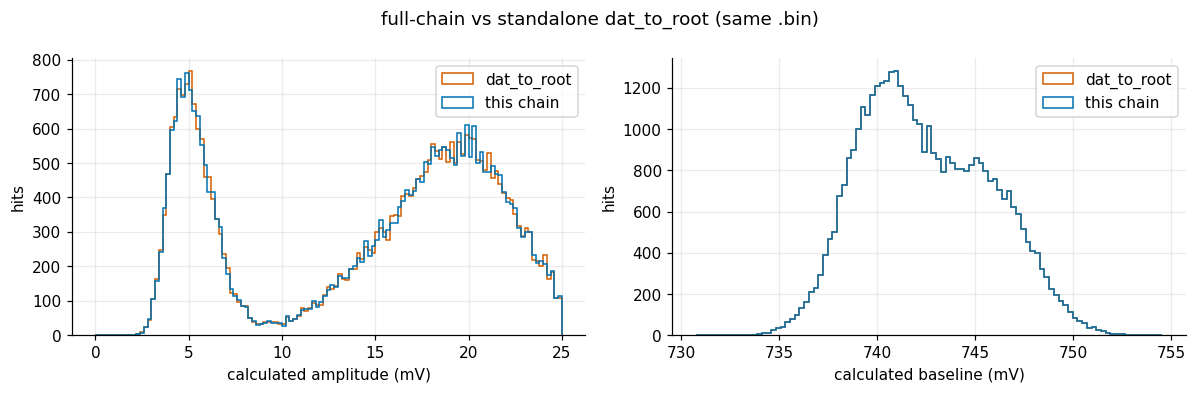

In [8]:
import uproot

ref = uproot.open(REFERENCE_FILE)["wfms"]
R = ref.arrays(["Channel", "BaselineCalculated", "AmplitudeCalculated",
                "WaveformData"], library="np")
print(f"reference hits: {ref.num_entries}  (chain: {len(D['channel'])})")
assert ref.num_entries == len(D["channel"])

amp_sub = dev[:, 3:62]
ipk_rel = np.abs(amp_sub).argmax(axis=1)
amp_calc = amp_sub[np.arange(len(amp_sub)), ipk_rel]
ipk = ipk_rel + 3

d_base = np.abs(base_calc - R["BaselineCalculated"]).max()
d_amp_mag = np.abs(np.abs(amp_calc) - np.abs(R["AmplitudeCalculated"])).max()
flips = np.abs(amp_calc - R["AmplitudeCalculated"]) > 1e-6
wf_ref0 = np.asarray(R["WaveformData"][0])
d_wf0 = np.abs(D["wf"][0] - wf_ref0).max()
print(f"baseline    max |diff|: {d_base:.3g} V")
print(f"|amplitude| max |diff|: {d_amp_mag:.3g} V")
print(f"waveform0   max |diff|: {d_wf0:.3g} V")
print(f"amplitude sign flips  : {flips.sum()} hits (noise waveforms where")
print("  +/- peaks tie within float32; the AD bank carries float32 while")
print("  dat_to_root computes in double)")
assert d_base < 1e-6 and d_amp_mag < 1e-6 and d_wf0 < 1e-6

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
bins_a = np.linspace(0, 25, 126)
axes[0].hist(R["AmplitudeCalculated"] * 1e3, bins=bins_a, color=C_REF,
             histtype="step", lw=2, label="dat_to_root")
axes[0].hist(amp_calc * 1e3, bins=bins_a, color=C_MAIN, histtype="step",
             lw=1.5, ls="--", label="this chain")
axes[0].set_xlabel("calculated amplitude (mV)")
axes[0].set_ylabel("hits")
axes[0].legend()
bins_b = np.linspace(R["BaselineCalculated"].min() * 1e3 - 1,
                     R["BaselineCalculated"].max() * 1e3 + 1, 100)
axes[1].hist(R["BaselineCalculated"] * 1e3, bins=bins_b, color=C_REF,
             histtype="step", lw=2, label="dat_to_root")
axes[1].hist(base_calc * 1e3, bins=bins_b, color=C_MAIN, histtype="step",
             lw=1.5, ls="--", label="this chain")
axes[1].set_xlabel("calculated baseline (mV)")
axes[1].set_ylabel("hits")
axes[1].legend()
fig.suptitle("full-chain vs standalone dat_to_root (same .bin)")
fig.tight_layout()
plt.show()

## Event-building diagnostic

Distribution of the time gap between consecutive hits. The chosen `--gap-ns`
must sit in a depopulated region: gaps below it are within-event structure,
gaps above it are separate triggers. (With a single active channel at ~700 Hz,
essentially every hit is its own event.)

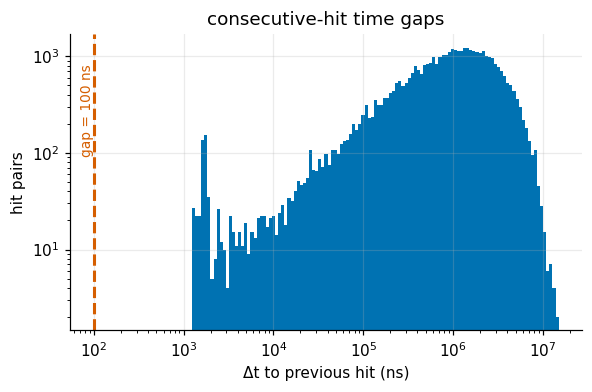

In [9]:
dt_hits = np.diff(np.sort(D["t0"]))
dt_hits = dt_hits[dt_hits > 0]

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.logspace(np.log10(max(dt_hits.min(), 0.1)),
                   np.log10(dt_hits.max()), 120)
ax.hist(dt_hits, bins=bins, color=C_MAIN)
ax.axvline(GAP_NS, color=C_REF, lw=2, ls="--")
ax.annotate(f"gap = {GAP_NS:.0f} ns", xy=(GAP_NS, 0.9),
            xycoords=("data", "axes fraction"), rotation=90,
            va="top", ha="right", fontsize=9, color=C_REF)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Δt to previous hit (ns)")
ax.set_ylabel("hit pairs")
ax.set_title("consecutive-hit time gaps")
plt.show()

## Outlook — reconstruction hooks

What these waveforms feed next, all consuming `/Event/SampicEvent` in Gaudi:

- **Energy calibration** — pulse integral (the reference uses `Trunc10`:
  peak-anchored sum minus baseline, last 10 samples dropped) → charge via the
  4700 Ω transimpedance → MeV via 0.0225 MeV/fC. Compare against `hEnergy`.
- **Pulse fitting** — fit the amplitude-normalized template (above) per hit for
  amplitude/time; residuals vs the SAMPIC front-end measurements.
- **Timing** — CFD or template time vs `first_cell_timestamp` + `time_instant`;
  needs multi-channel runs for coincidences (the event builder already groups
  them once more channels are enabled).